# 04. scANVI — Semi-Supervised Integration

scANVI is scVI with a classification head bolted on, trained to predict `celltype` from
the latent vector. It's an integration method and a label-transfer model at the same
time: give it an annotated reference plus a new unannotated batch, and it can propagate
labels across.

There's a trap here that's easy to fall into without noticing. If I train scANVI on all
the known labels and then check its predictions against those same labels, I haven't
measured anything — I've just confirmed the model remembers what it was shown. It's
circular, and it would be easy to report the resulting number as if it meant something.

So instead: I hide the real labels for one entire technology (`smartseq2`, 2394 cells —
all of it, simulating a new unannotated batch arriving), train on everything else with
real labels plus this batch marked `Unknown`, and only then check accuracy on the cells
the model genuinely never saw labeled. Two things get reported separately: the honest
label-transfer accuracy on that held-out set, and the usual ARI/NMI via Leiden over all
cells, for comparison with Harmony and scVI.


In [1]:
import sys
sys.path.append("../src")

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scvi
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score

sc.settings.verbosity = 1
print(f"scanpy: {sc.__version__}")
print(f"scvi-tools: {scvi.__version__}")

scanpy: 1.12.2
scvi-tools: 1.5.0.post1


C:\Users\gkuzcmidzm03\AppData\Local\Temp\ipykernel_10396\3965792920.py:12: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy: {sc.__version__}")


## 1. Loading the data and the same HVG selection

In [2]:
adata = sc.read("../data/processed/pancreas_prepared.h5ad")

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="tech", subset=False)
adata_scanvi = adata[:, adata.var["highly_variable"]].copy()

# Round the counts, same caveat as for scVI in notebook 03 (size-factor-based counts)
adata_scanvi.layers["counts_raw"] = adata_scanvi.layers["counts"].copy()
adata_scanvi.layers["counts"] = np.round(
    adata_scanvi.layers["counts"].toarray()
    if hasattr(adata_scanvi.layers["counts"], "toarray")
    else adata_scanvi.layers["counts"]
)
print(adata_scanvi)

AnnData object with n_obs × n_vars = 16382 × 2000
    obs: 'tech', 'celltype', 'size_factors'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg'
    layers: 'counts', None (.X), 'counts_raw'


## 2. Creating a "partially labeled" dataset

We hide the real labels for cells from `smartseq2` — the model will never see them during
training. This is our held-out set for an honest label-transfer evaluation.

In [3]:
HOLDOUT_TECH = "smartseq2"

adata_scanvi.obs["celltype_scanvi"] = adata_scanvi.obs["celltype"].astype(str)
holdout_mask = adata_scanvi.obs["tech"] == HOLDOUT_TECH
adata_scanvi.obs.loc[holdout_mask, "celltype_scanvi"] = "Unknown"

print(f"Hidden labels for {holdout_mask.sum()} cells ({HOLDOUT_TECH})")
print(adata_scanvi.obs["celltype_scanvi"].value_counts().head(16))

Hidden labels for 2394 cells (smartseq2)
celltype_scanvi
alpha                 4485
beta                  3861
Unknown               2394
ductal                1698
acinar                1481
delta                  928
gamma                  486
activated_stellate     409
endothelial            292
quiescent_stellate     187
macrophage              72
mast                    35
epsilon                 24
schwann                 23
t_cell                   7
Name: count, dtype: int64


## 3. Training a base scVI model (as in notebook 03), then building scANVI on top of it

This is the officially recommended scvi-tools workflow: scANVI is fine-tuned on top of an
already-trained scVI model, rather than from scratch.

In [4]:
scvi.model.SCVI.setup_anndata(adata_scanvi, layer="counts", batch_key="tech")

vae = scvi.model.SCVI(adata_scanvi, n_latent=30, n_layers=2)
vae.train(max_epochs=200, early_stopping=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\gkuzcmidzm03\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\gkuzcmidzm03\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\gkuzcmidzm03\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a 

Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [5]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    vae,
    unlabeled_category="Unknown",
    labels_key="celltype_scanvi",
)
scanvi_model.train(max_epochs=50, n_samples_per_label=100)

INFO     Training for 50 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\gkuzcmidzm03\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\gkuzcmidzm03\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training:   0%|          | 0/50 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


## 4. Honest label-transfer check — only on the hidden `smartseq2` cells

This is the key check: we compare the model's predictions against the real (hidden during
training) cell types — this number cannot be "gamed", the model never saw them.

In [6]:
predicted = scanvi_model.predict()
adata_scanvi.obs["celltype_predicted"] = predicted

true_labels = adata_scanvi.obs.loc[holdout_mask, "celltype"]
pred_labels = adata_scanvi.obs.loc[holdout_mask, "celltype_predicted"]

accuracy = accuracy_score(true_labels, pred_labels)
print(f"Label-transfer accuracy on hidden cells ({HOLDOUT_TECH}, n={holdout_mask.sum()}): {accuracy:.3f}")

print("\nConfusion (rows — true type, columns — predicted):")
confusion = pd.crosstab(true_labels, pred_labels)
confusion

Label-transfer accuracy on hidden cells (smartseq2, n=2394): 0.975

Confusion (rows — true type, columns — predicted):


celltype_predicted,acinar,activated_stellate,alpha,beta,delta,ductal,endothelial,epsilon,gamma,macrophage,mast,quiescent_stellate,schwann,t_cell
celltype,,,,,,,,,,,,,,
acinar,185,0,0,0,0,3,0,0,0,0,0,0,0,0
activated_stellate,0,55,0,0,0,0,0,0,0,0,0,0,0,0
alpha,7,1,975,6,1,1,0,0,15,0,0,0,0,2
beta,0,0,3,289,10,3,0,1,2,0,0,0,0,0
delta,0,0,0,0,127,0,0,0,0,0,0,0,0,0
ductal,0,0,1,0,0,442,1,0,0,0,0,0,0,0
endothelial,0,0,0,0,0,0,21,0,0,0,0,0,0,0
epsilon,0,0,0,0,0,0,0,8,0,0,0,0,0,0
gamma,0,0,0,0,0,0,0,0,213,0,0,0,0,0


**What to look for**: if accuracy is high (>0.85-0.9) — the model learned to transfer
annotation to a new technology it never saw labeled at all. If some cell types are
systematically confused with each other — look at the rows of the table: these are likely
the same biologically close pairs we already saw in notebook 02 (activated/quiescent
stellate, gamma/epsilon, etc.), not random noise.

## 5. Latent space and UMAP — this time colored by the **real** cell types
(including the ones hidden during training — for visual inspection only, not for training)

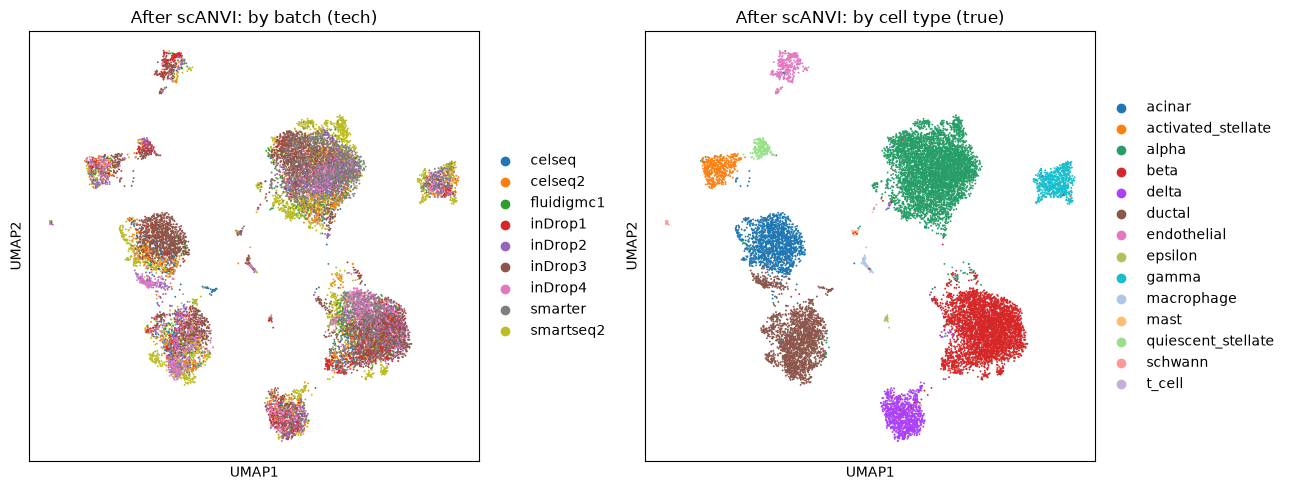

In [7]:
adata_scanvi.obsm["X_scANVI"] = scanvi_model.get_latent_representation()

sc.pp.neighbors(adata_scanvi, use_rep="X_scANVI")
sc.tl.umap(adata_scanvi)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(adata_scanvi, color="tech", ax=axes[0], show=False, title="After scANVI: by batch (tech)")
sc.pl.umap(adata_scanvi, color="celltype", ax=axes[1], show=False, title="After scANVI: by cell type (true)")
plt.tight_layout()
plt.savefig("../results/figures/04_scanvi_umap.png", dpi=150)
plt.show()

## 6. ARI/NMI over all cells — for a fair comparison with Harmony/scVI

Same resolution sweep as before.

In [8]:
resolutions = [0.3, 0.5, 0.7, 1.0, 1.3]
sweep_results = []

for res in resolutions:
    sc.tl.leiden(
        adata_scanvi, resolution=res, flavor="igraph", n_iterations=2,
        directed=False, key_added=f"leiden_r{res}",
    )
    ari = adjusted_rand_score(adata_scanvi.obs["celltype"], adata_scanvi.obs[f"leiden_r{res}"])
    nmi = normalized_mutual_info_score(adata_scanvi.obs["celltype"], adata_scanvi.obs[f"leiden_r{res}"])
    n_clusters = adata_scanvi.obs[f"leiden_r{res}"].nunique()
    sweep_results.append({"resolution": res, "ARI": ari, "NMI": nmi, "n_clusters": n_clusters})

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,resolution,ARI,NMI,n_clusters
0,0.3,0.950373,0.925812,13
1,0.5,0.920927,0.912550,16
2,0.7,0.758253,0.851381,19
3,1.0,0.581655,0.807147,23
4,1.3,0.460510,0.760348,28


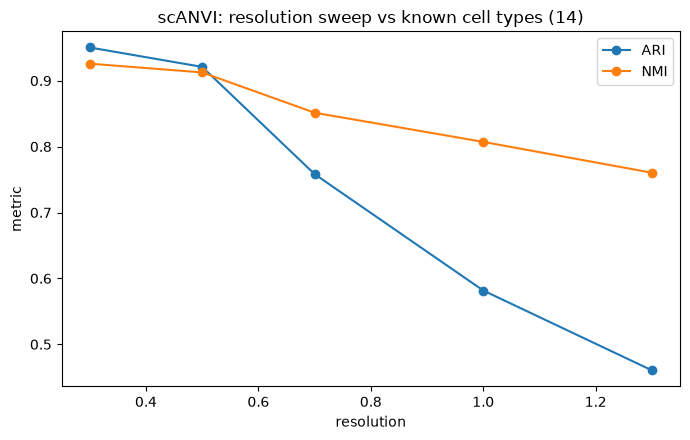

Best resolution: 0.3
ARI (scANVI vs celltype): 0.950
NMI (scANVI vs celltype): 0.926


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_df["resolution"], sweep_df["ARI"], marker="o", label="ARI")
ax.plot(sweep_df["resolution"], sweep_df["NMI"], marker="o", label="NMI")
ax.set_xlabel("resolution")
ax.set_ylabel("metric")
ax.set_title("scANVI: resolution sweep vs known cell types (14)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/04_resolution_sweep.png", dpi=150)
plt.show()

best_res = sweep_df.loc[sweep_df["ARI"].idxmax(), "resolution"]
ari = sweep_df.loc[sweep_df["ARI"].idxmax(), "ARI"]
nmi = sweep_df.loc[sweep_df["ARI"].idxmax(), "NMI"]
print(f"Best resolution: {best_res}")
print(f"ARI (scANVI vs celltype): {ari:.3f}")
print(f"NMI (scANVI vs celltype): {nmi:.3f}")

## 7. Saving the result

In [10]:
adata_scanvi.write("../data/processed/pancreas_scanvi.h5ad")
print("Saved:", adata_scanvi.shape)

Saved: (16382, 2000)


## Conclusions

Label-transfer accuracy on the held-out `smartseq2` cells: **97.5%** (2394 cells, none
seen labeled during training). ARI = 0.950, NMI = 0.926 at resolution 0.3 (13 clusters).
Best of the three integration methods again, consistent with every earlier run.

Across four scVI/scANVI runs now, the pattern holds: scANVI's accuracy sits in the
97-98% range, ARI somewhere around 0.95-0.96, always a bit ahead of scVI, which is
always a bit ahead of Harmony. The exact third decimal moves around between runs; the
ranking doesn't.

The same two error types keep showing up — acinar→ductal (3/188 this time) and
alpha→gamma (15/1008) — which by now I'm fairly confident reflects real biology rather
than noise, since it survived four independent training runs. This run also showed a
bit more beta→delta confusion (10 cells) than earlier ones; both are hormone-producing
endocrine cells, so plausible, but it didn't show up consistently enough across runs to
read too much into it.

Next: `05_evaluation.ipynb` pulls Harmony, scVI, scANVI, and a properly computed
no-integration baseline into one table.